In [1]:
import matplotlib
import os
import logging
from marss2l.utils import setup_stream_logger, fs_from_path

logger = logging.getLogger(__name__)
setup_stream_logger(logger, level=logging.DEBUG)

/home/gonzalo/mambaforge/envs/marss2ltacopy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%%time
from marss2l import dataframe_image_plumes
from marss2l.huggingface import CSV_PATH_DEFAULT_HF, CSV_PLUME_PATH_DEFAULT_HF

# path_images = "../data/validated_images_all.csv"
# path_prepend_data = "../data/"
# path_plumes = "../data/validated_images_plumes_fixed.csv"
# path_sources = "../data/loc_sources.csv"

# Load images and plumes from HuggingFace
path_images = CSV_PATH_DEFAULT_HF
path_plumes = CSV_PLUME_PATH_DEFAULT_HF

fs = fs_from_path(path_images)

dataframe_images = dataframe_image_plumes.read_csv_images(path_images, fs=fs,path_prepend_data=None)
dataframe_plumes = dataframe_image_plumes.read_csv_plumes(path_plumes, fs=fs)
dataframe_sources = None
# dataframe_sources = dataframe_image_plumes.read_csv_locs_sources(path_sources, fs=fs_local)

CPU times: user 43.4 s, sys: 1.76 s, total: 45.1 s
Wall time: 54.7 s


In [3]:
%%time
split = "train_2023"

dataframe_image_train, dataframe_plumes_train, dataframe_sources_train = dataframe_image_plumes.load_dataframe_split(
        dataframe_or_csv_path=dataframe_images,
        dataframe_or_csv_path_plumes=dataframe_plumes,
        dataframe_or_csv_path_sources=dataframe_sources,
        split=split,
        fs=fs,
        logger=logger,
        all_locs=None,
        load_plumes=True
    )

CPU times: user 2.36 s, sys: 128 ms, total: 2.49 s
Wall time: 2.5 s


In [4]:
from marss2l import loaders
# from importlib import reload
# reload(loaders)
from marss2l import loss
# reload(loss)
import json
import os

mode = "train"

dataset = loaders.DatasetPlumes(mode=mode,
                        device="cpu",
                        image_dataframe=dataframe_image_train,
                        plume_dataframe=dataframe_plumes_train,
                        sources_dataframe=dataframe_sources_train,
                        logger=logger,
                        film_dict_mapping=None,
                        film_train_zero_id=None,
                        analysis_mode=True,
                        rotate_data_augmentation=True,
                        fs=fs)
dataset.image_dataframe.shape

2025-12-02 07:57:39,124 - __main__ - INFO - train_2023 train. There are 421 locations that have less than 30 samples
2025-12-02 07:57:39,138 - __main__ - INFO - train_2023 train. There are 325 locations that have less than 15 negative samples
2025-12-02 07:57:39,148 - __main__ - INFO - train_2023 train. There are 527 locations that have less than 5 positive samples
2025-12-02 07:57:39,164 - __main__ - INFO - There are 3694 samples and 3592 negative samples in total in locations with few samples or few negative samples.
2025-12-02 07:57:39,210 - __main__ - INFO - train_2023 train data from 618 locations
2025-12-02 07:57:39,363 - __main__ - INFO - train_2023 train data between 2018-01-01 09:13:51+00:00 to 2023-11-30 10:33:09+00:00
2025-12-02 07:57:39,364 - __main__ - INFO - train_2023 train data size 38345 with 3512 plumes and 34833 images without plumes
2025-12-02 07:57:39,369 - __main__ - INFO - train_2023 train Satellites in the dataset: ['S2B' 'S2A' 'LC08' 'LC09']
2025-12-02 07:57:39

(38345, 56)

2025-12-02 07:57:48,640 - __main__ - DEBUG - Sampled location EMIT_CH4_PlumeComplex-2130 with few samples or no negative samples
2025-12-02 07:57:48,650 - __main__ - DEBUG - 	Sampled no plume: AZE_fut23qn5x LC08 2023-09-01 79980b39-2673-4da4-8f76-7fbcf6074bad


ERROR! Session/line number was not unique in database. History logging moved to new session 6838


2025-12-02 07:57:49,932 - __main__ - DEBUG - Using MBMP for onshore location AZE_fut23qn5x
2025-12-02 07:57:49,946 - __main__ - DEBUG - 		 Rotating image 270 degrees


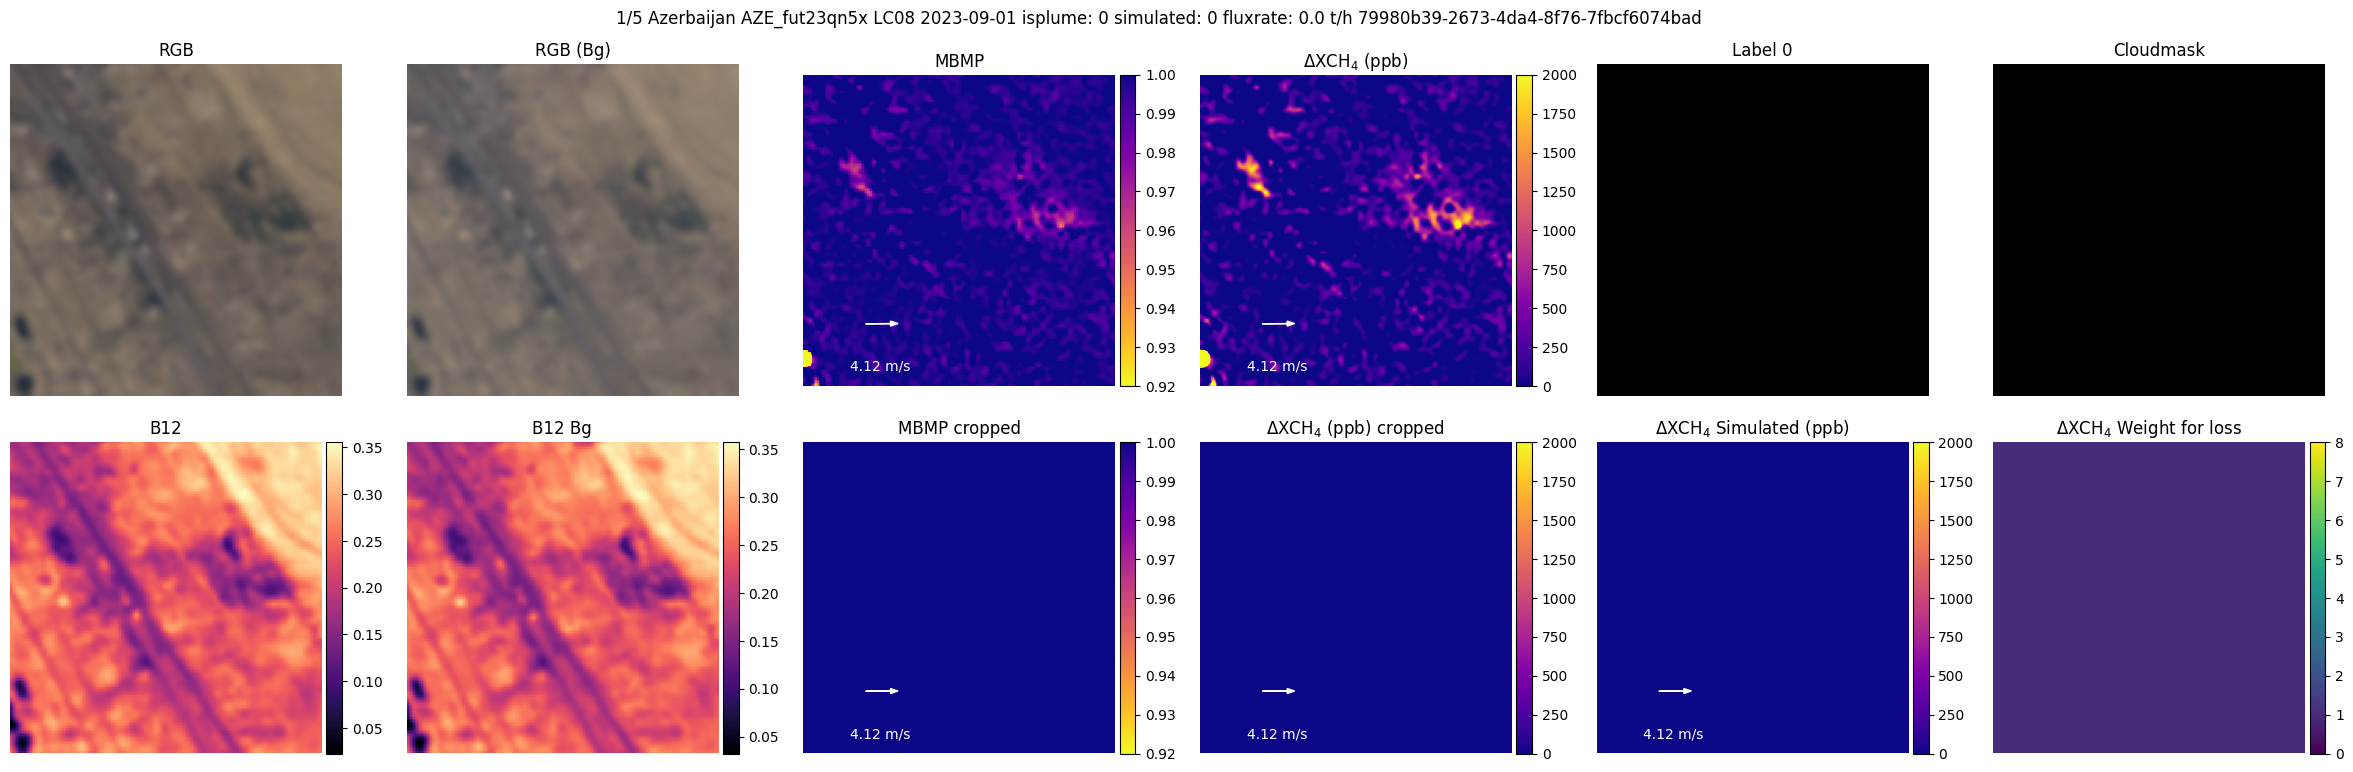

2025-12-02 07:57:54,271 - __main__ - INFO - SNR: NA Time sampling: 1.326s time plotting: 4.305s
2025-12-02 07:57:54,286 - __main__ - DEBUG - Sampled location EMIT_CH4_PlumeComplex-1705
2025-12-02 07:57:54,290 - __main__ - DEBUG - 	Sampling plume
2025-12-02 07:57:54,291 - __main__ - DEBUG - 	 loc with 0 plumes. Simulate: True
2025-12-02 07:57:55,463 - __main__ - DEBUG - 		Sampled no plume image: EMIT_CH4_PlumeComplex-1705 2023-10-08 S2B wind speed: 1.47m/s observability: clear fbbac93a-920e-472a-bef0-2fd299721faf
2025-12-02 07:57:55,465 - __main__ - DEBUG - 		Searching for plumes to simulate with fluxrate between 3.5 and 70.0 t/h
2025-12-02 07:57:55,470 - __main__ - DEBUG - 		Found 610 plumes with fluxrate in [3.5, 70.0]t/h and wind speed within 1.50m/s of 1.47m/s
2025-12-02 07:57:56,473 - __main__ - DEBUG - 		 Not simulating plume on source
2025-12-02 07:57:56,475 - __main__ - DEBUG - 		 Simulating plume from image T_0 S2A 2023-05-19 fluxrate: 6.4t/h fbbac93a-920e-472a-bef0-2fd299721fa

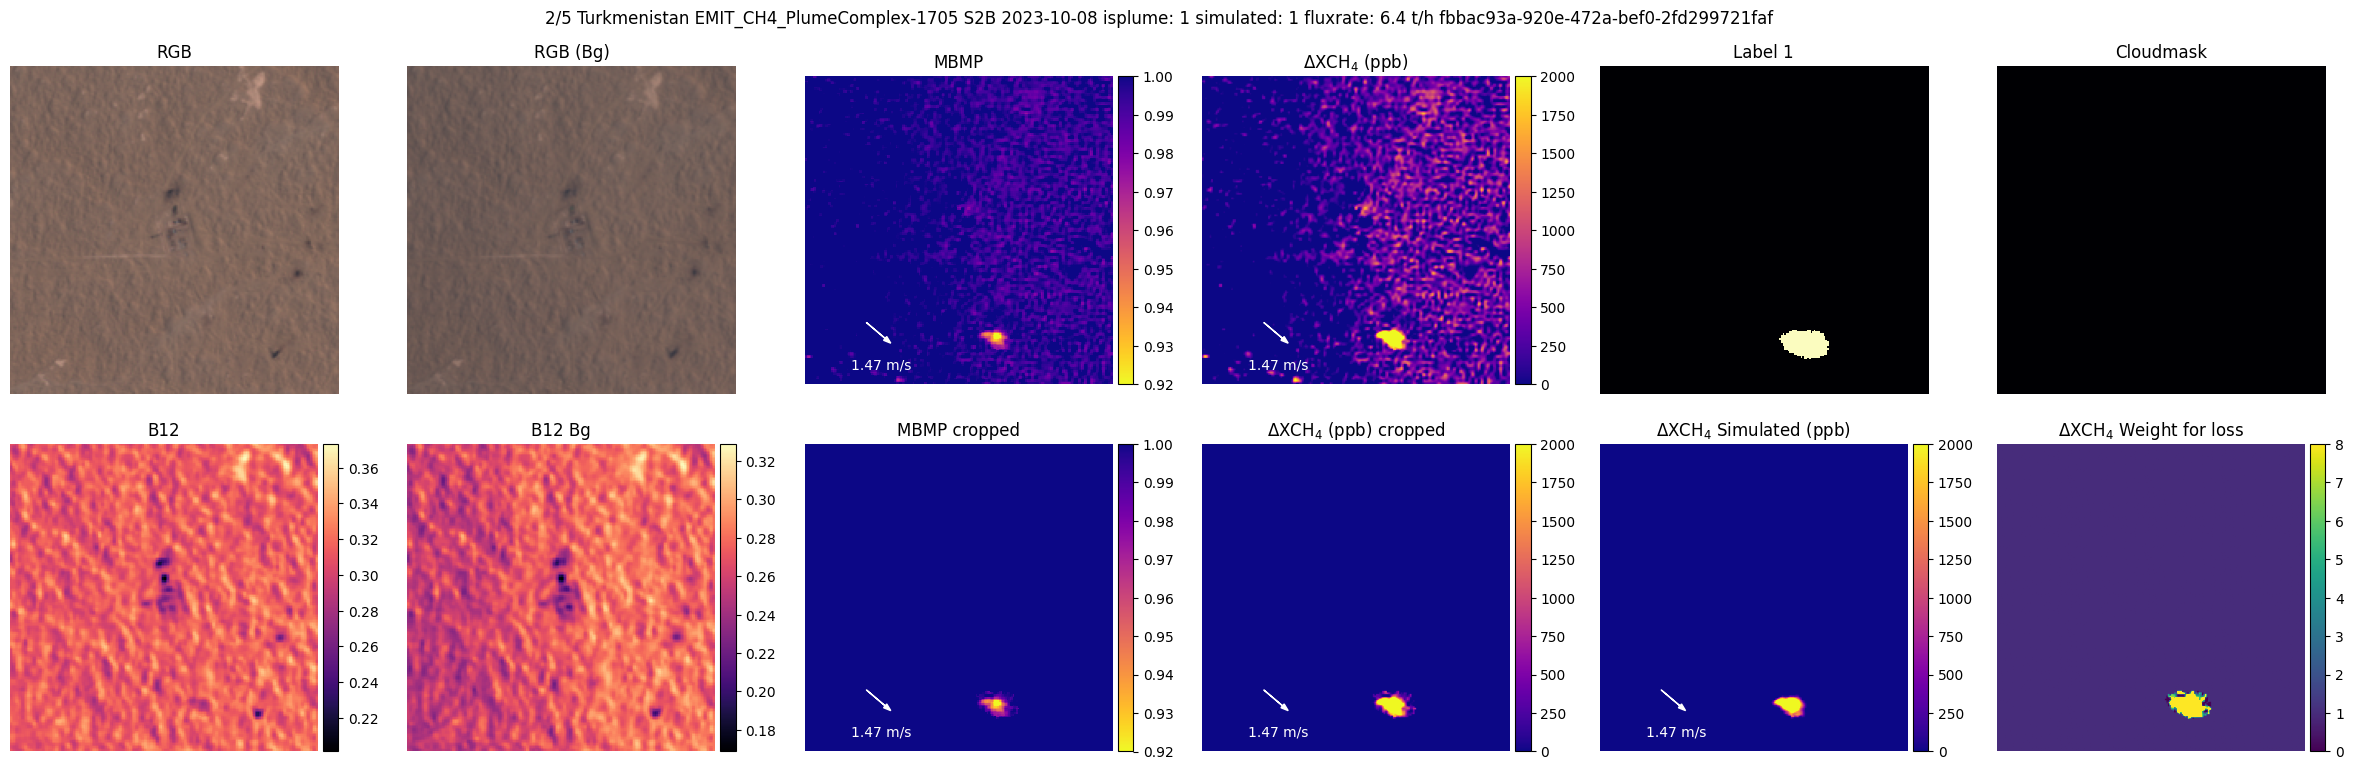

2025-12-02 07:58:01,766 - __main__ - INFO - SNR: 7.9083 Time sampling: 3.031s time plotting: 4.458s
2025-12-02 07:58:01,778 - __main__ - DEBUG - Sampled location PB_K_0001
2025-12-02 07:58:01,782 - __main__ - DEBUG - 	Sampled no plume: PB_K_0001 S2B 2023-10-07 9d022f1c-c68f-441d-a23d-5871f2b7e1ab
2025-12-02 07:58:03,608 - __main__ - DEBUG - Using MBMP for onshore location PB_K_0001
2025-12-02 07:58:03,621 - __main__ - DEBUG - 		 Rotating image 270 degrees


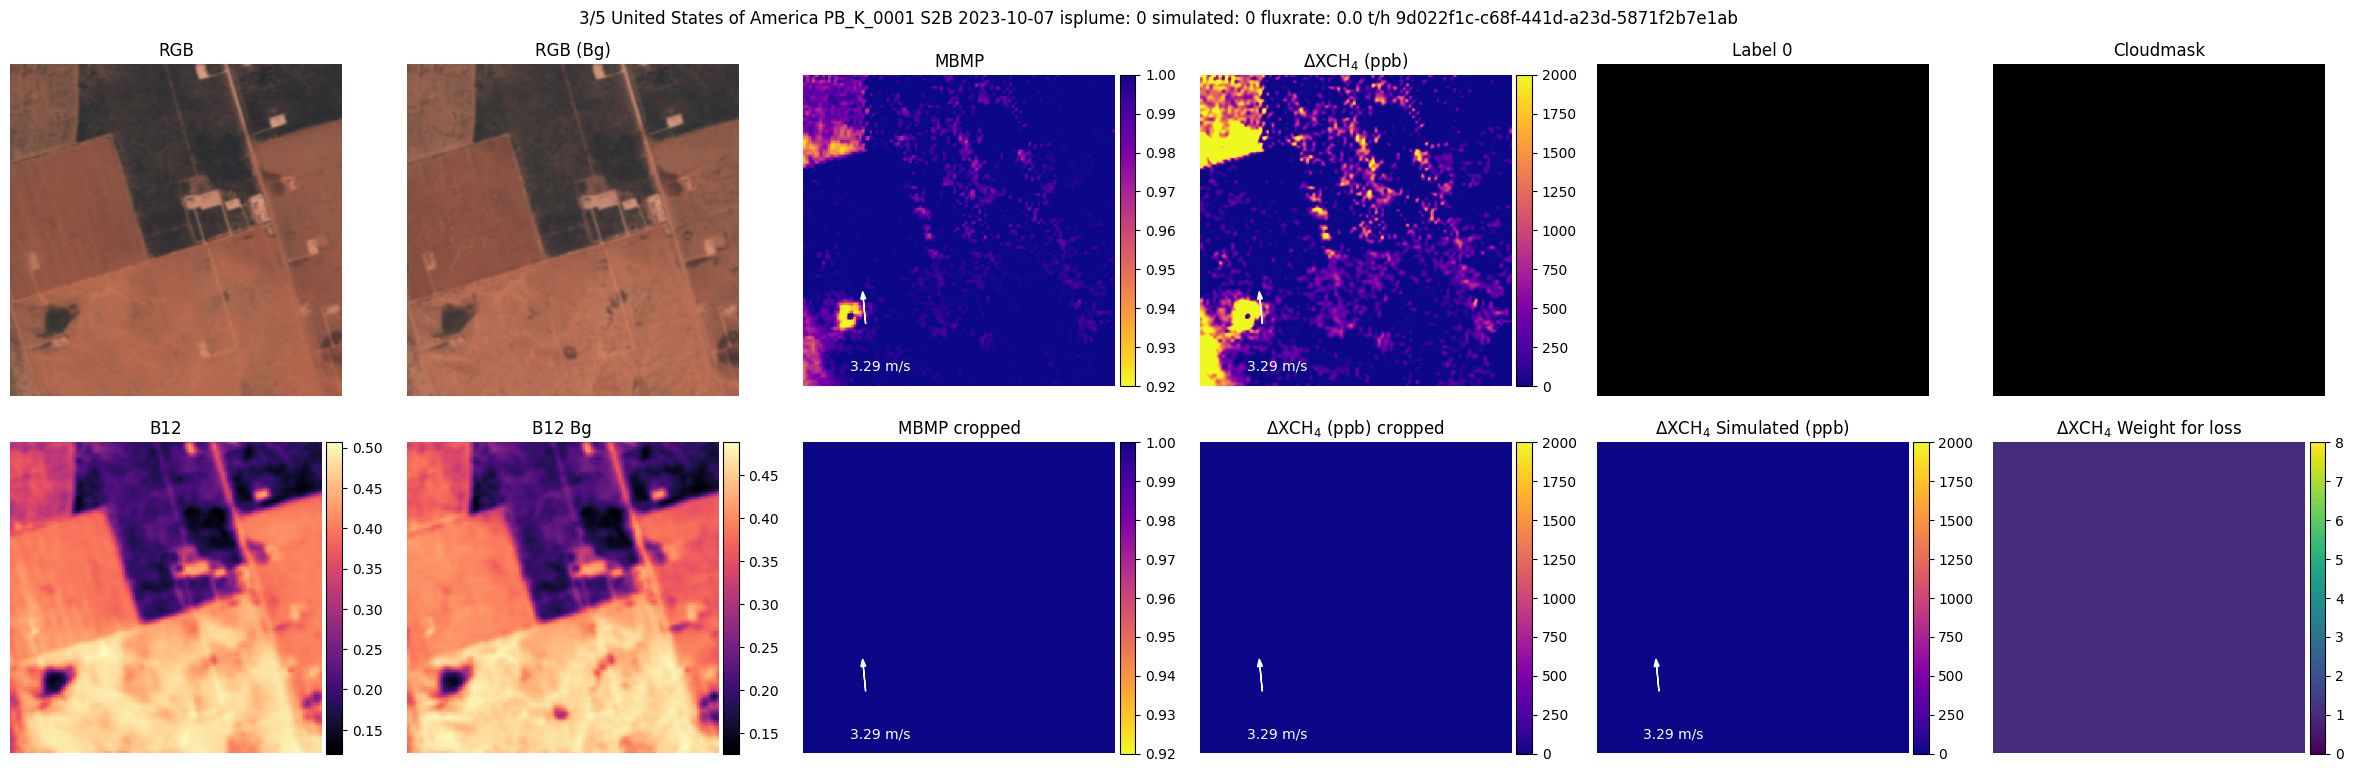

2025-12-02 07:58:08,020 - __main__ - INFO - SNR: NA Time sampling: 1.871s time plotting: 4.382s
2025-12-02 07:58:08,031 - __main__ - DEBUG - Sampled location EMIT_CH4_PlumeComplex-350
2025-12-02 07:58:08,033 - __main__ - DEBUG - 	Sampling plume
2025-12-02 07:58:08,034 - __main__ - DEBUG - 	 loc with 12 plumes. Simulate: True
2025-12-02 07:58:09,237 - __main__ - DEBUG - 		Sampled no plume image: EMIT_CH4_PlumeComplex-350 2023-11-28 S2A wind speed: 2.83m/s observability: clear 95722d09-4cd6-4b04-af41-67a9509cb2e9
2025-12-02 07:58:09,239 - __main__ - DEBUG - 		Searching for plumes to simulate with fluxrate between 3.5 and 70.0 t/h
2025-12-02 07:58:09,244 - __main__ - DEBUG - 		Found 1017 plumes with fluxrate in [3.5, 70.0]t/h and wind speed within 1.50m/s of 2.83m/s
2025-12-02 07:58:09,517 - __main__ - DEBUG - 		 Not simulating plume on source
2025-12-02 07:58:09,519 - __main__ - DEBUG - 		 Simulating plume from image Te_N_5 LC08 2023-07-19 fluxrate: 5.4t/h 95722d09-4cd6-4b04-af41-67a9509

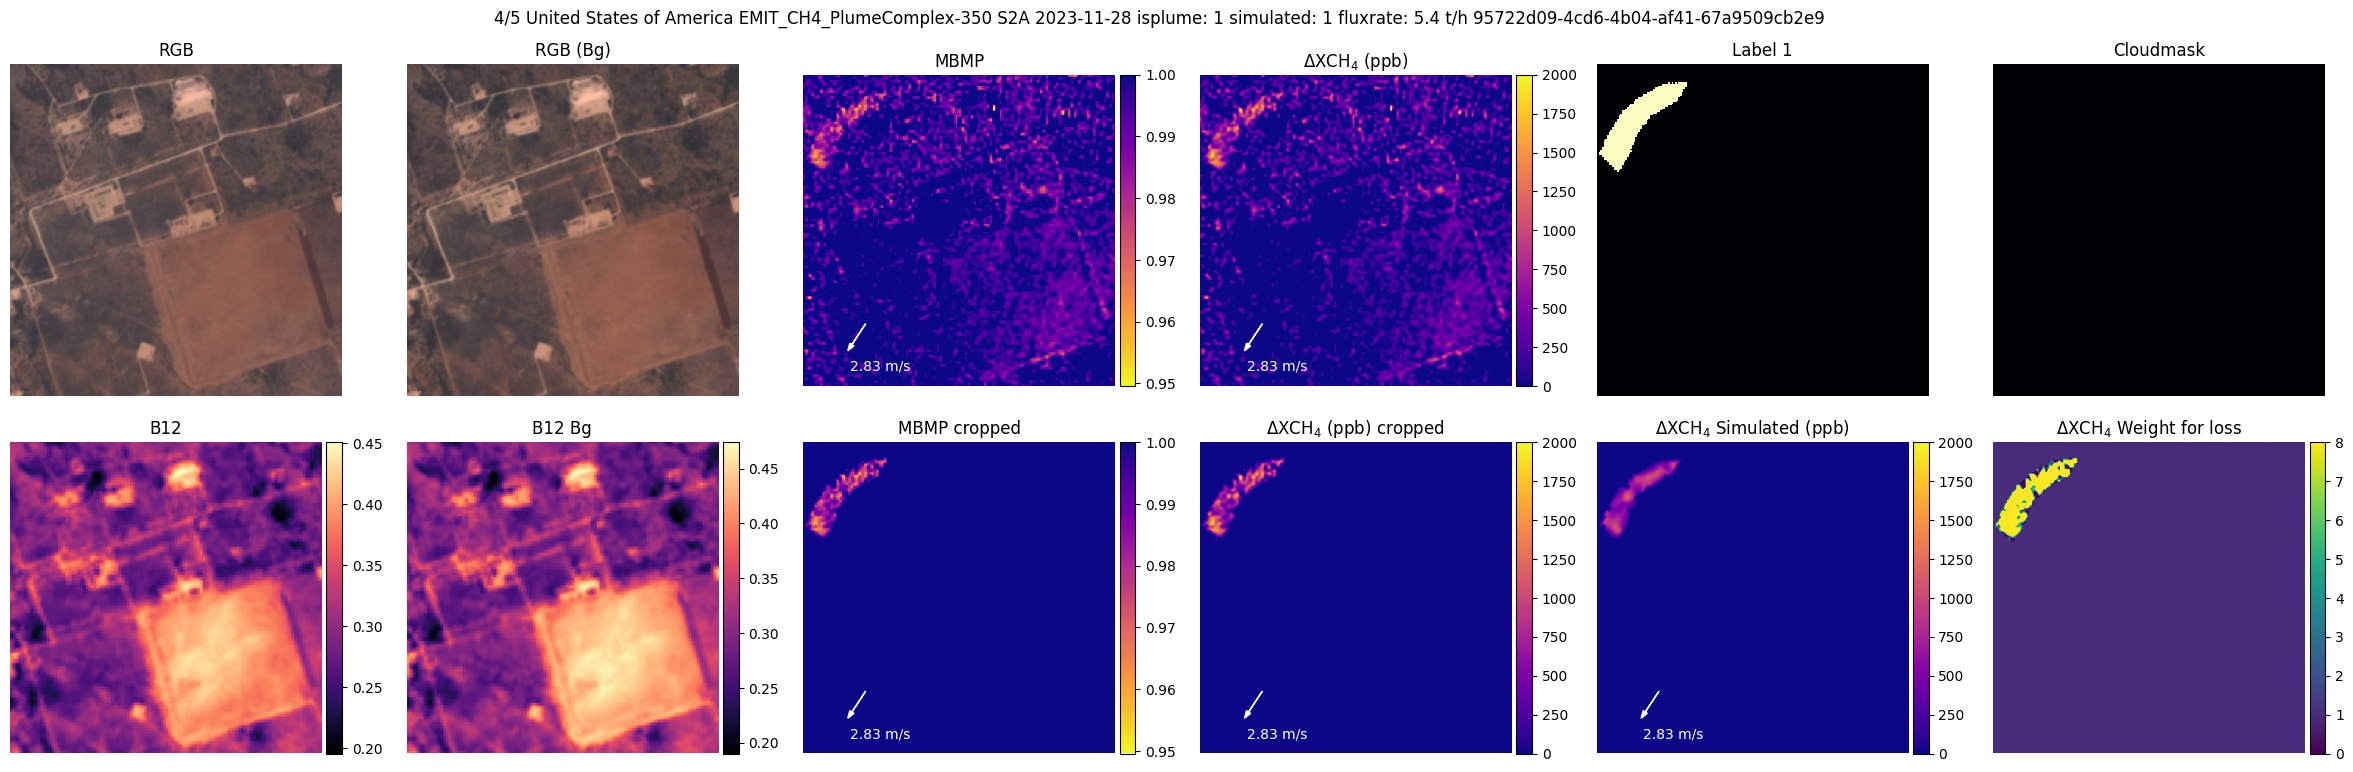

2025-12-02 07:58:14,575 - __main__ - INFO - SNR: 5.3741 Time sampling: 1.812s time plotting: 4.740s
2025-12-02 07:58:14,587 - __main__ - DEBUG - Sampled location Iq_9
2025-12-02 07:58:14,590 - __main__ - DEBUG - 	Sampled no plume: Iq_9 LC09 2023-04-11 e83ee7b4-40dc-42b8-a634-368658acc71e
2025-12-02 07:58:16,090 - __main__ - DEBUG - Using MBMP for onshore location Iq_9
2025-12-02 07:58:16,104 - __main__ - DEBUG - 		 Rotating image 180 degrees


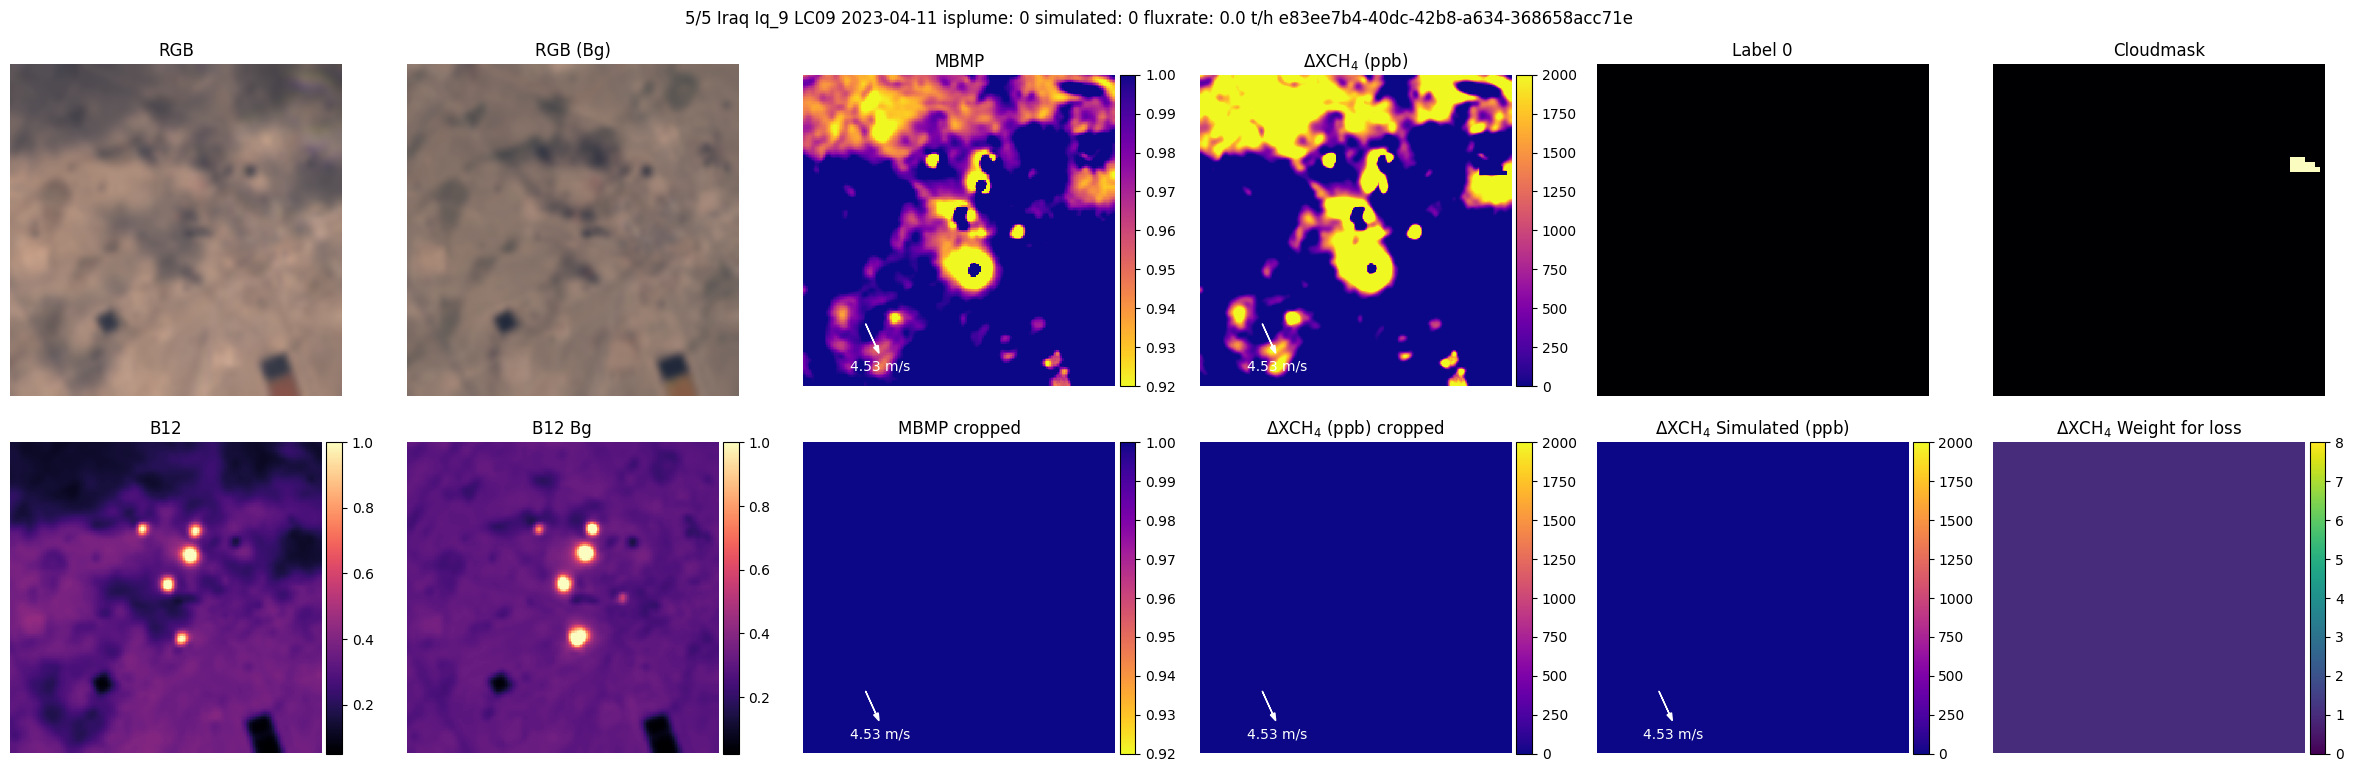

2025-12-02 07:58:20,376 - __main__ - INFO - SNR: NA Time sampling: 1.543s time plotting: 4.257s


In [5]:
import matplotlib.pyplot as plt
from marss2l.loss import get_snr
import time
from marss2l.loss import DEFAULT_POS_WEIGHT

total = 5
for _i in range(total):
    start = time.time()
    sample = dataset[_i]
    time_sampling = time.time()-start
    fig, axs = dataset.plot_item(sample, text_prepend=f"{_i+1}/{total}", pos_weight=DEFAULT_POS_WEIGHT)
    plt.show(fig)
    plt.close(fig)
    time_plotting = time.time() - start - time_sampling
    if sample["isplume"].item() == 1:
        snr = get_snr(sample["ch4"], sample["y_target"], keepdim=False).item()
        snr_text = f"{snr:.4f}"
    else:
        snr_text = "NA"
    
    logger.info(f"SNR: {snr_text} Time sampling: {time_sampling:.3f}s time plotting: {time_plotting:.3f}s")

## Only sample simulated images

2025-12-02 08:06:57,153 - __main__ - DEBUG - 		Sampled no plume image: K_2 2022-07-29 S2A wind speed: 3.21m/s observability: clear 08d9f744-f34a-47fa-9805-3ca1b8fccfd2
2025-12-02 08:06:57,155 - __main__ - DEBUG - 		Searching for plumes to simulate with fluxrate between 3.5 and 70.0 t/h
2025-12-02 08:06:57,160 - __main__ - DEBUG - 		Found 1073 plumes with fluxrate in [3.5, 70.0]t/h and wind speed within 1.50m/s of 3.21m/s
2025-12-02 08:06:57,454 - __main__ - DEBUG - 		 Not simulating plume on source
2025-12-02 08:06:57,455 - __main__ - DEBUG - 		 Simulating plume from image T_1 LC08 2019-07-08 fluxrate: 17.8t/h 08d9f744-f34a-47fa-9805-3ca1b8fccfd2
2025-12-02 08:06:58,075 - __main__ - DEBUG - Using MBMP for onshore location K_2


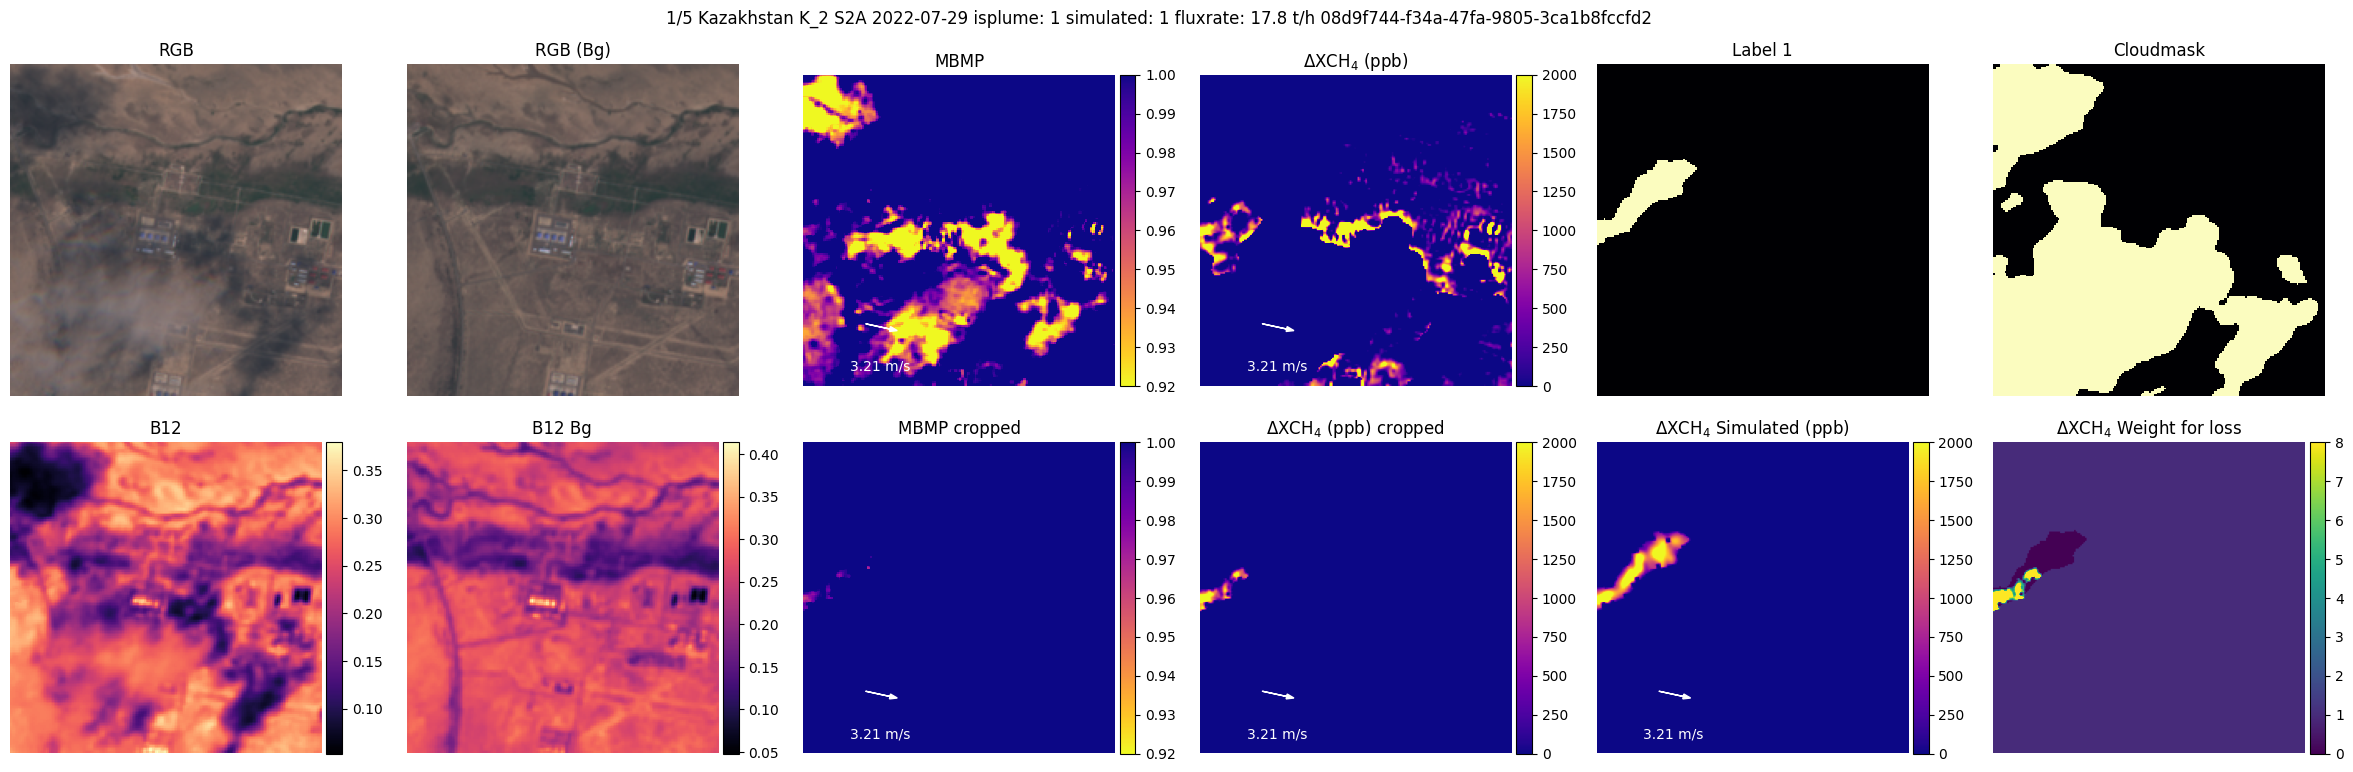

2025-12-02 08:07:02,483 - __main__ - INFO - SNR: 2.3927 Time sampling: 2.465s time plotting: 4.379s
2025-12-02 08:07:03,604 - __main__ - DEBUG - 		Sampled no plume image: K_S_2 2022-08-04 S2B wind speed: 6.20m/s observability: clear 5dae719b-8500-4243-bcee-14471db13adc
2025-12-02 08:07:03,605 - __main__ - DEBUG - 		Searching for plumes to simulate with fluxrate between 3.5 and 70.0 t/h
2025-12-02 08:07:03,610 - __main__ - DEBUG - 		Found 666 plumes with fluxrate in [3.5, 70.0]t/h and wind speed within 1.50m/s of 6.20m/s
2025-12-02 08:07:04,832 - __main__ - DEBUG - 		 Not simulating plume on source
2025-12-02 08:07:04,833 - __main__ - DEBUG - 		 Simulating plume from image K_7 S2B 2022-09-29 fluxrate: 3.2t/h 5dae719b-8500-4243-bcee-14471db13adc
2025-12-02 08:07:05,750 - __main__ - DEBUG - Using MBMP for onshore location K_S_2


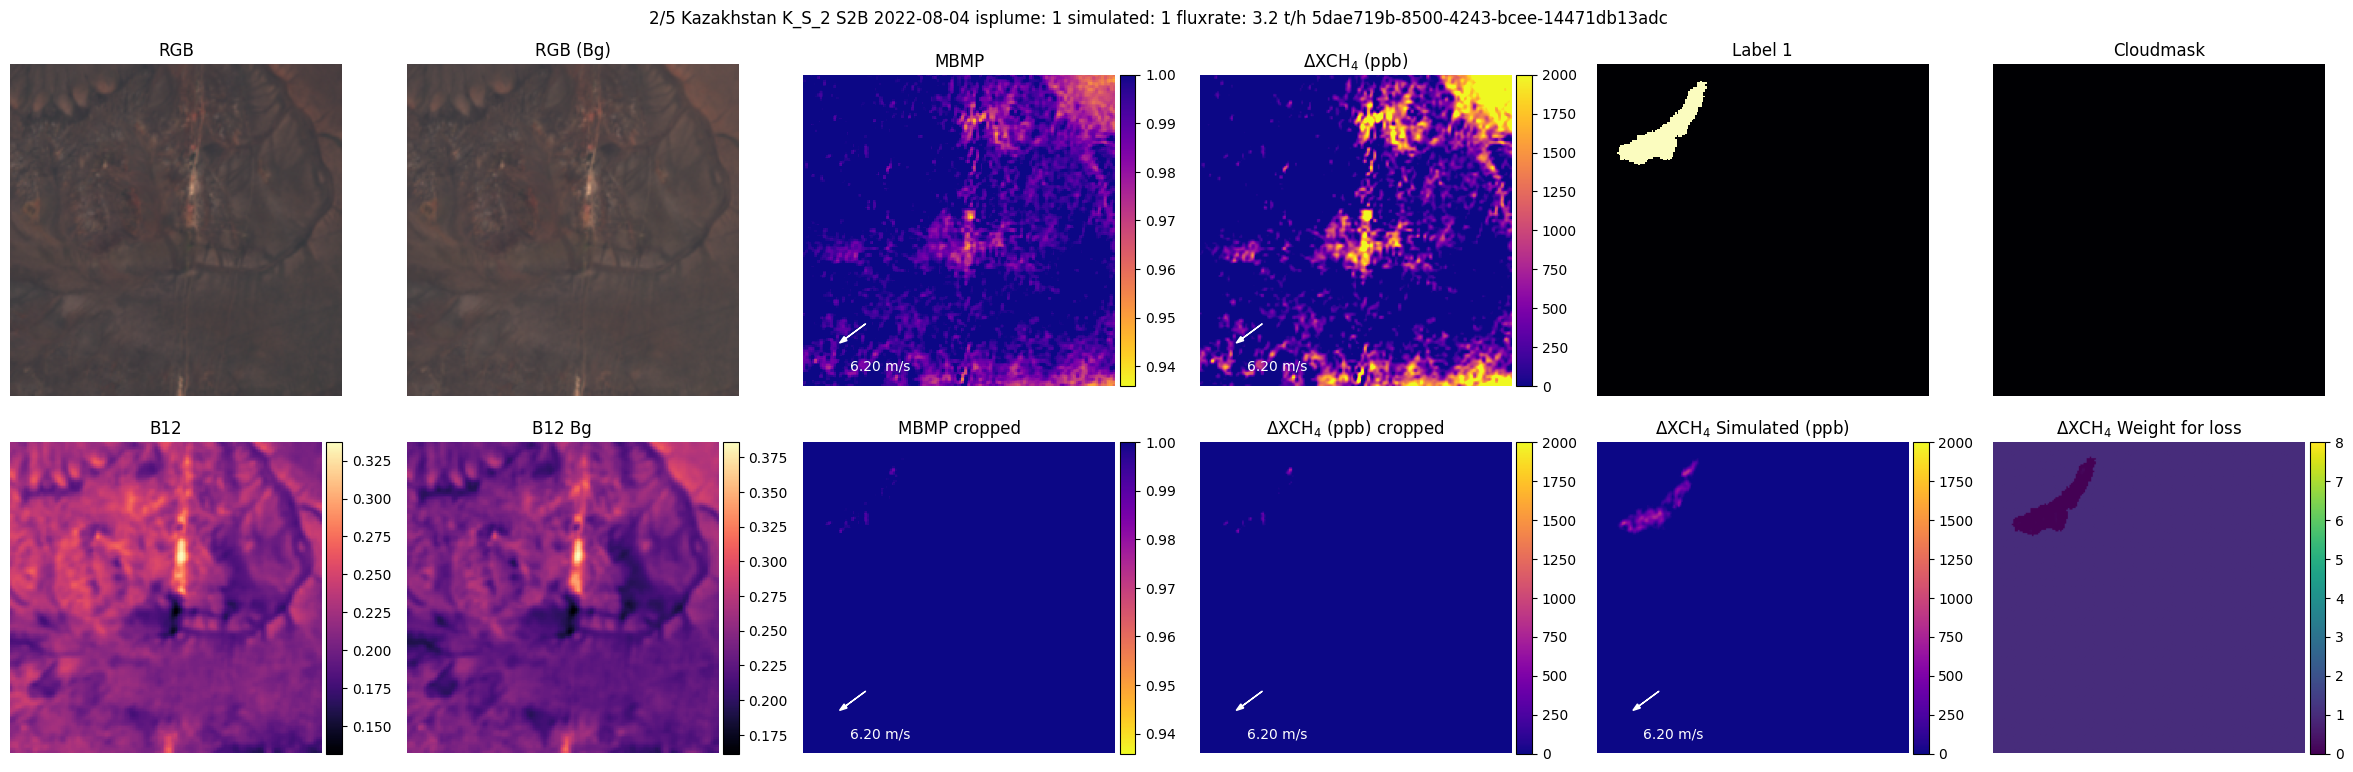

2025-12-02 08:07:10,124 - __main__ - INFO - SNR: 0.0609 Time sampling: 3.294s time plotting: 4.344s
2025-12-02 08:07:11,330 - __main__ - DEBUG - 		Sampled no plume image: A_38 2022-05-13 S2B wind speed: 5.73m/s observability: clear e3612f7b-d9fe-4d55-8f15-4a7d9e95f5b6
2025-12-02 08:07:11,331 - __main__ - DEBUG - 		Searching for plumes to simulate with fluxrate between 3.5 and 70.0 t/h
2025-12-02 08:07:11,337 - __main__ - DEBUG - 		Found 781 plumes with fluxrate in [3.5, 70.0]t/h and wind speed within 1.50m/s of 5.73m/s
2025-12-02 08:07:11,720 - __main__ - DEBUG - 		 Not simulating plume on source
2025-12-02 08:07:11,722 - __main__ - DEBUG - 		 Simulating plume from image T_0 LC08 2018-07-05 fluxrate: 42.5t/h e3612f7b-d9fe-4d55-8f15-4a7d9e95f5b6
2025-12-02 08:07:12,011 - __main__ - DEBUG - Using MBMP for onshore location A_38
2025-12-02 08:07:12,026 - __main__ - DEBUG - 		 Rotating image 180 degrees


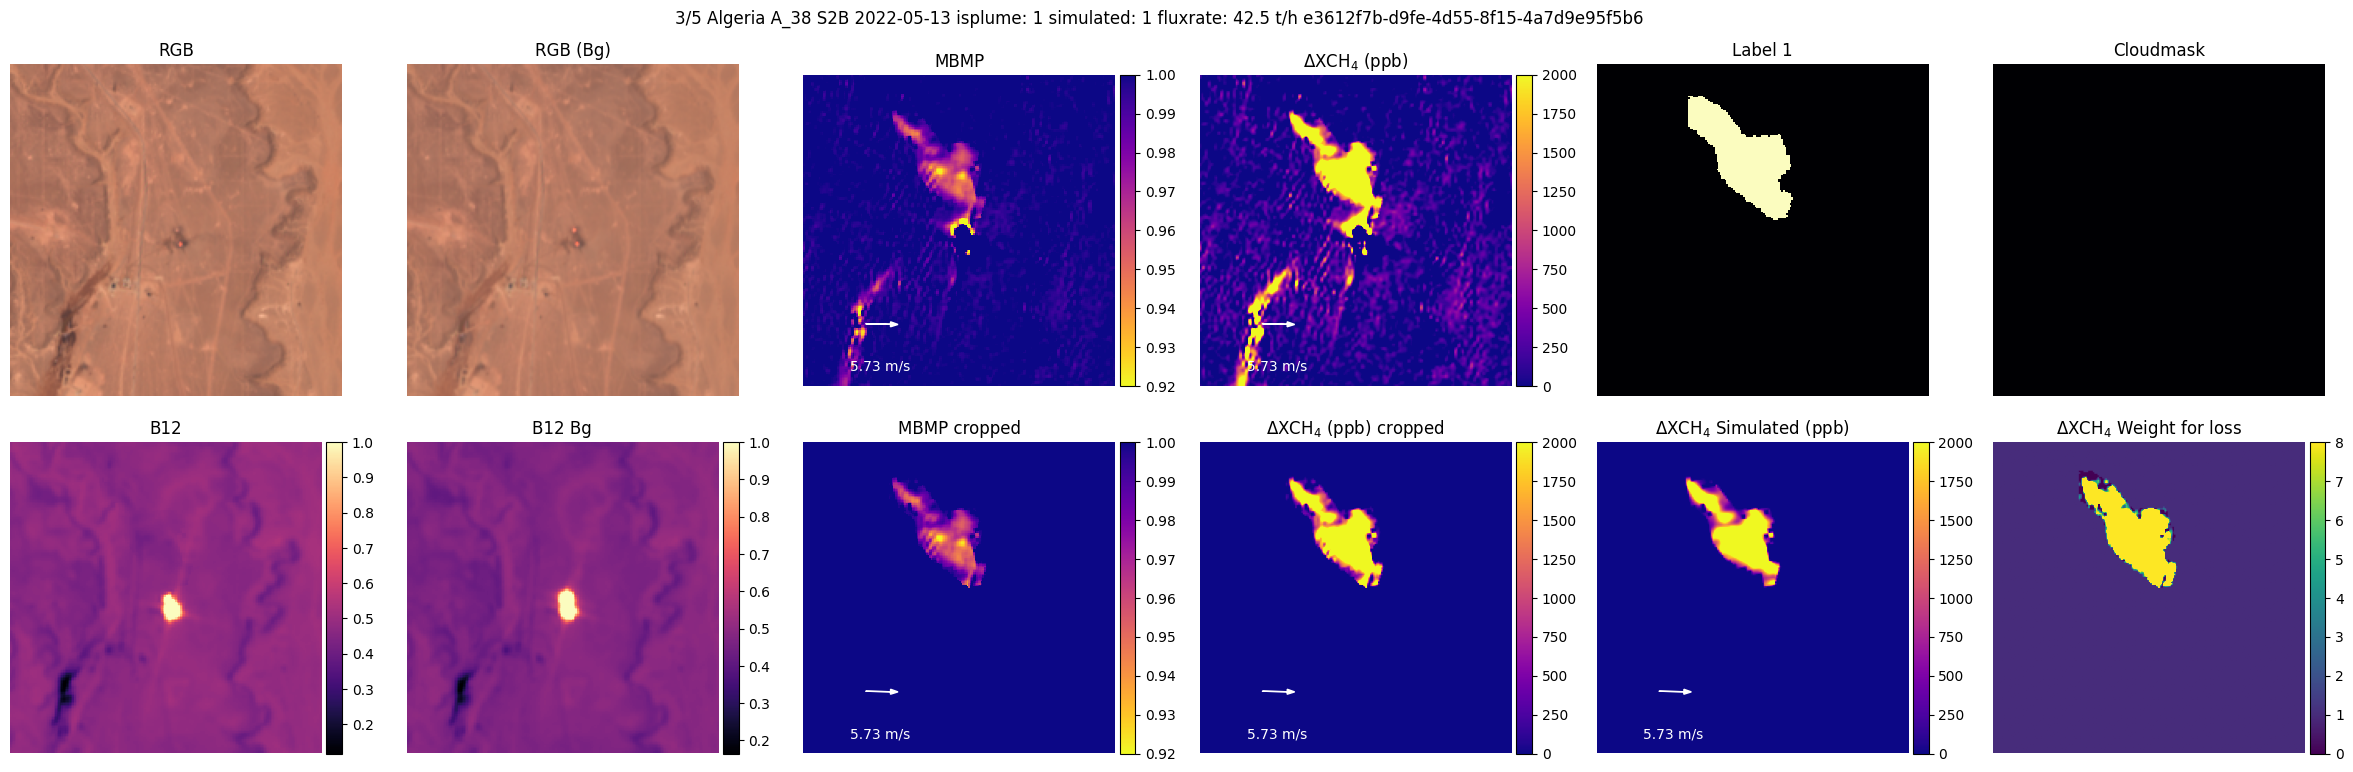

2025-12-02 08:07:16,450 - __main__ - INFO - SNR: 12.4207 Time sampling: 1.916s time plotting: 4.407s
2025-12-02 08:07:17,584 - __main__ - DEBUG - 		Sampled no plume image: GA_001 2019-02-25 S2A wind speed: 5.75m/s observability: clear e567512b-87f5-4953-abfc-55642dd2c1f2
2025-12-02 08:07:17,585 - __main__ - DEBUG - 		Searching for plumes to simulate with fluxrate between 3.5 and 70.0 t/h
2025-12-02 08:07:17,590 - __main__ - DEBUG - 		Found 780 plumes with fluxrate in [3.5, 70.0]t/h and wind speed within 1.50m/s of 5.75m/s
2025-12-02 08:07:18,578 - __main__ - DEBUG - 		 Not simulating plume on source
2025-12-02 08:07:18,579 - __main__ - DEBUG - 		 Simulating plume from image KWT_0001 LC09 2023-09-02 fluxrate: 2.9t/h e567512b-87f5-4953-abfc-55642dd2c1f2
2025-12-02 08:07:18,851 - __main__ - DEBUG - Using MBMP for onshore location GA_001
2025-12-02 08:07:18,865 - __main__ - DEBUG - 		 Rotating image 90 degrees


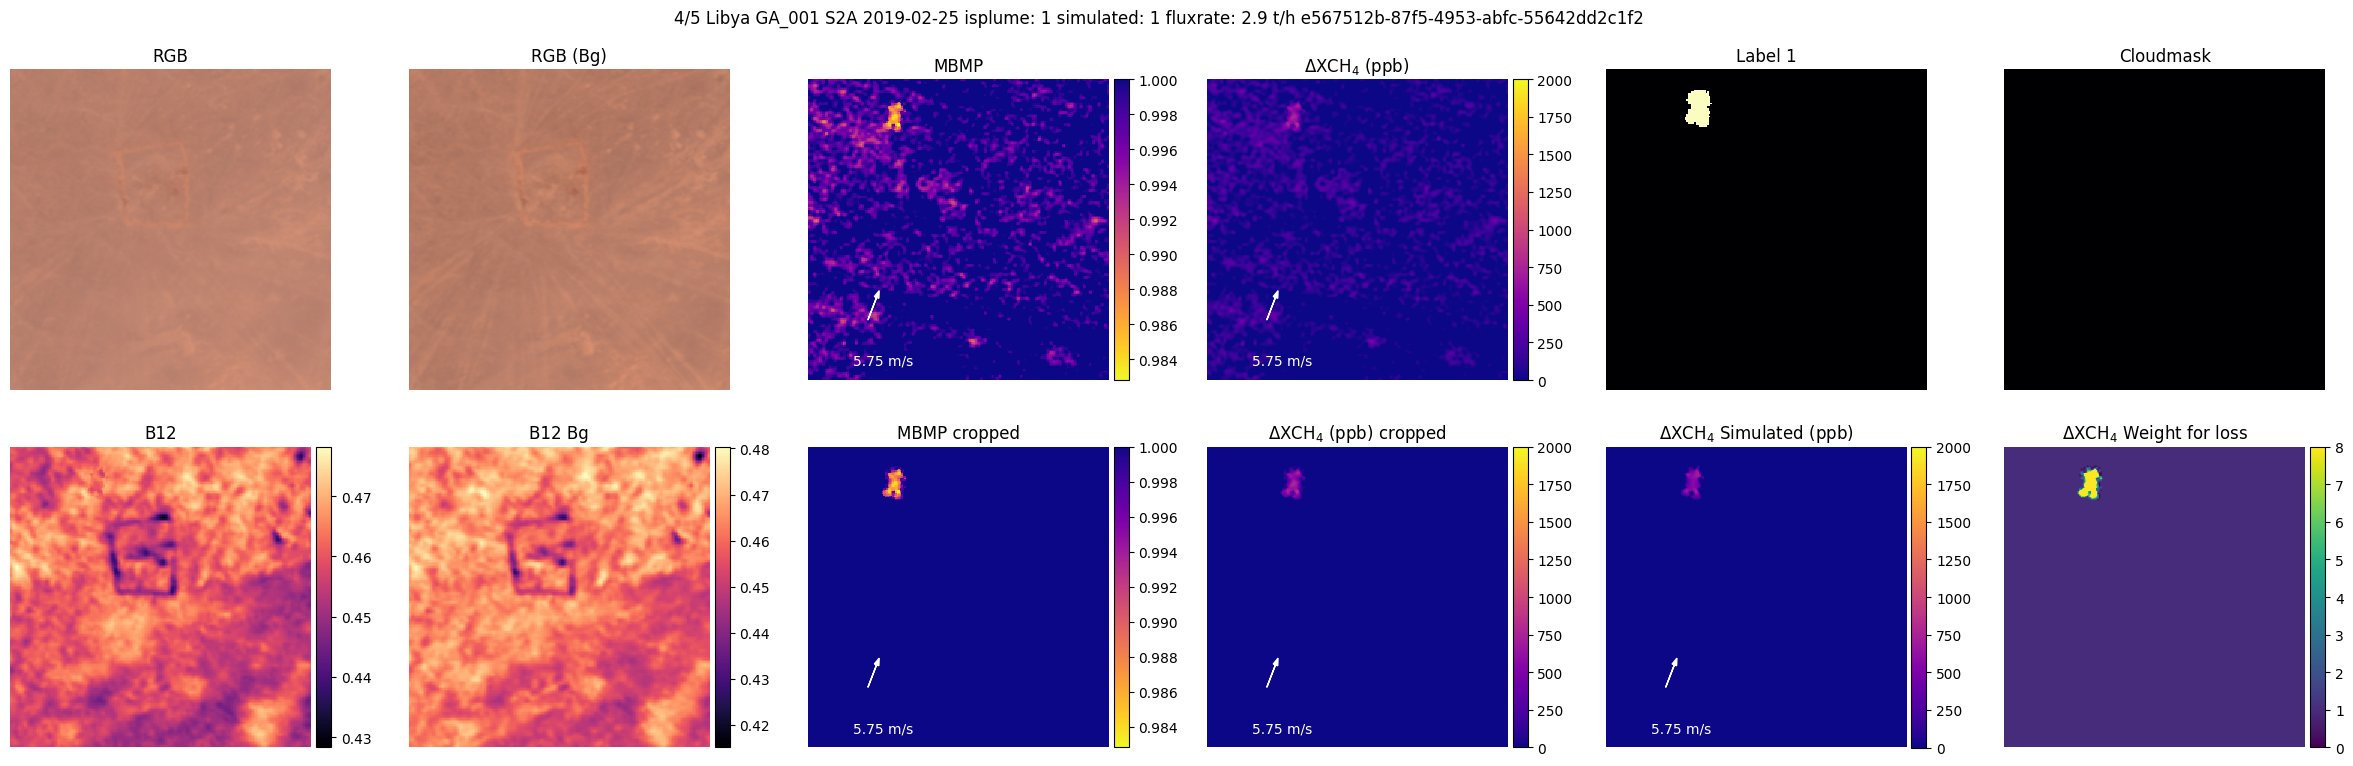

2025-12-02 08:07:23,860 - __main__ - INFO - SNR: 7.1541 Time sampling: 2.434s time plotting: 4.974s
2025-12-02 08:07:25,207 - __main__ - DEBUG - 		Sampled no plume image: A_7 2022-09-13 S2B wind speed: 3.74m/s observability: clear 34db975a-3738-4bd9-af30-5c661592a44f
2025-12-02 08:07:25,209 - __main__ - DEBUG - 		Searching for plumes to simulate with fluxrate between 3.5 and 70.0 t/h
2025-12-02 08:07:25,213 - __main__ - DEBUG - 		Found 1079 plumes with fluxrate in [3.5, 70.0]t/h and wind speed within 1.50m/s of 3.74m/s
2025-12-02 08:07:26,361 - __main__ - DEBUG - 		 Not simulating plume on source
2025-12-02 08:07:26,362 - __main__ - DEBUG - 		 Simulating plume from image T_23 LC08 2023-03-29 fluxrate: 2.1t/h 34db975a-3738-4bd9-af30-5c661592a44f
2025-12-02 08:07:26,669 - __main__ - DEBUG - Using MBMP for onshore location A_7
2025-12-02 08:07:26,682 - __main__ - DEBUG - 		 Rotating image 90 degrees


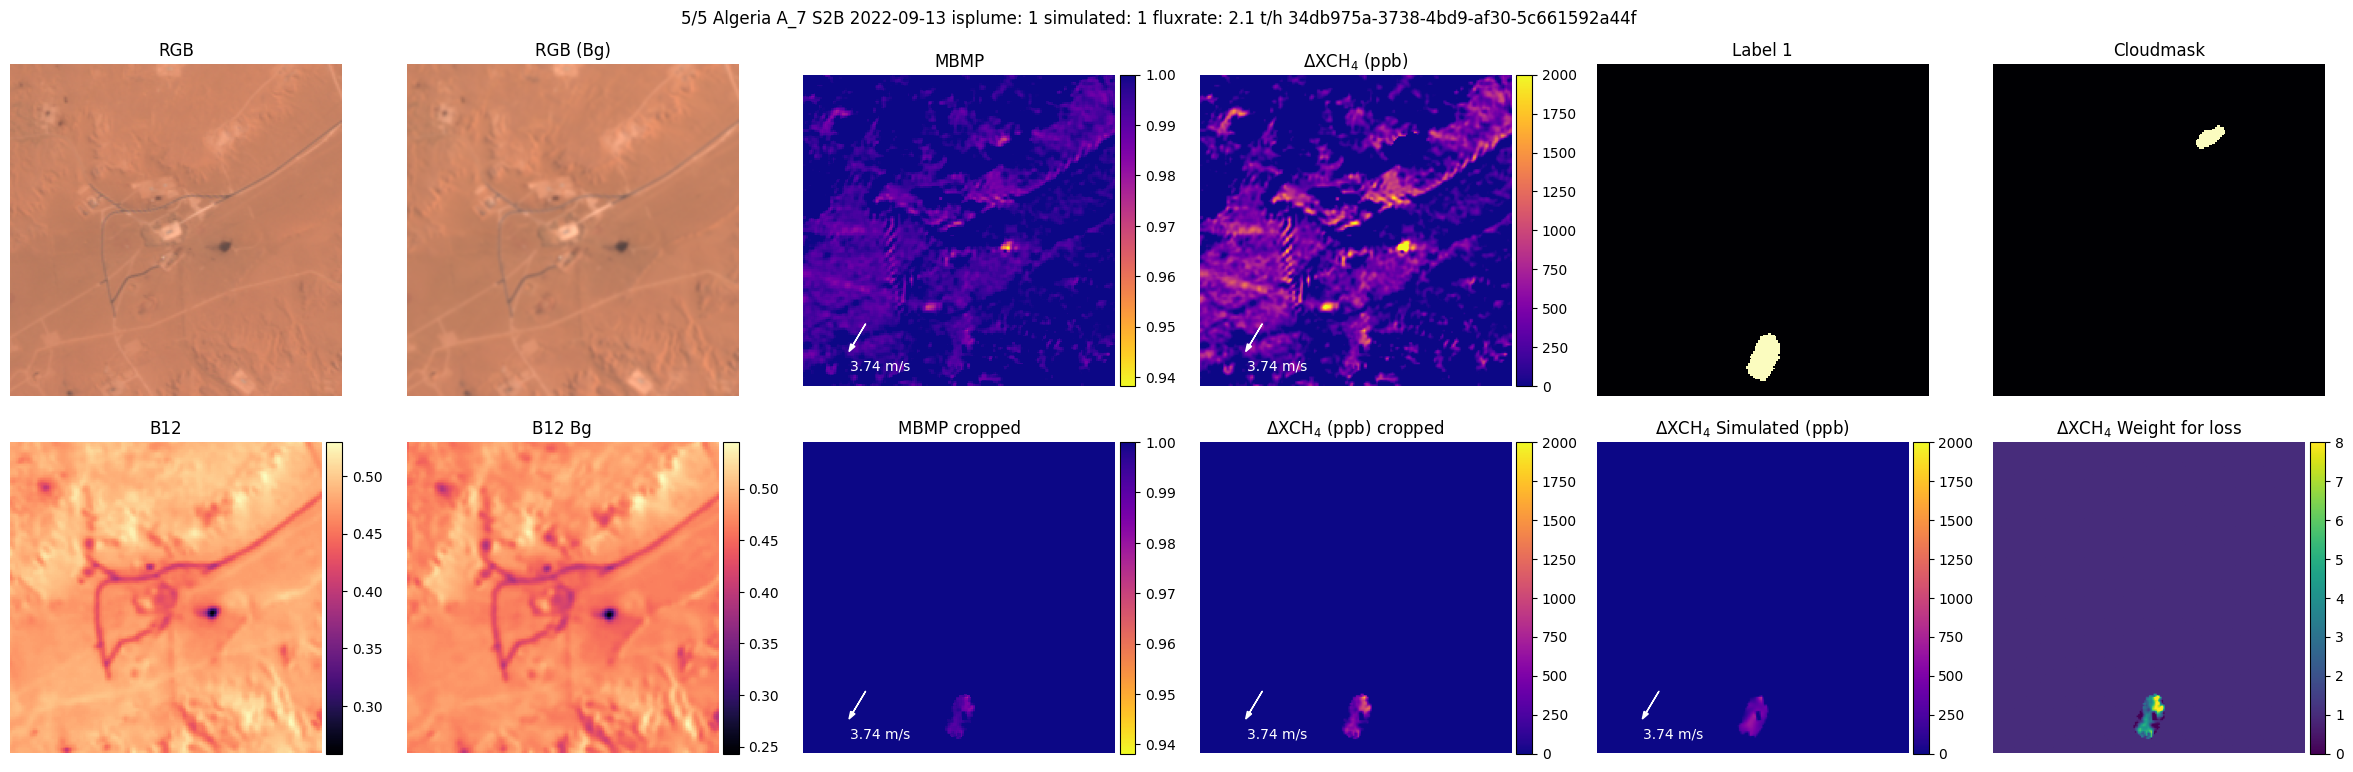

2025-12-02 08:07:30,981 - __main__ - INFO - SNR: 1.9735 Time sampling: 2.837s time plotting: 4.280s


In [8]:
total = 5
for _i in range(total):
    start = time.time()
    item_no_plume = dataset.sample_no_plume_image(None)
    sample = dataset.simulate_plume(item_no_plume)
    time_sampling = time.time()-start
    fig, axs = dataset.plot_item(sample, text_prepend=f"{_i+1}/{total}", pos_weight=DEFAULT_POS_WEIGHT)
    plt.show(fig)
    plt.close(fig)
    time_plotting = time.time() - start - time_sampling
    if sample["isplume"].item() == 1:
        snr = get_snr(sample["ch4"], sample["y_target"], keepdim=False).item()
        snr_text = f"{snr:.4f}"
    else:
        snr_text = "NA"
    
    logger.info(f"SNR: {snr_text} Time sampling: {time_sampling:.3f}s time plotting: {time_plotting:.3f}s")